# Wrapper methods 

feature selection are a type of methods that involves using a predictive model to score the combination of features. They are called wrappers methods because they wrap this type of model based evaluation around the feature selection proces
# Types of wrapper methods
1. Exhaustive feature selection
2. Forward Selection
3. Backward Elimination
4. Recursive feature Elimination

# Working of a Wrapper methods

1. Subset Generation
2. Subset Evaluation
3. Stopping Criterion

# Disadvantages

1. Computations Complexity : If you have n features then the number of combinations will be 2^n making this method expensive
2. Risk of Overfitting
3. Requires a good evaluation matric

1. Exhaustive Feature Selection

Idea: Try every possible combination of features, then choose the subset that gives the best model performance.

Process:

If you have 10 features, it checks:

All subsets of size 1 → pick best.

All subsets of size 2 → pick best.

… up to size 10.

Pros: Finds the globally best subset.

Cons: Very computationally expensive (number of subsets grows exponentially).

For 20 features → over 1 million subsets to check 😅.

👉 Think of it like brute force search.

🔹 2. Sequential Backward Elimination (SBE)

Idea: Start with all features, then remove one at a time until performance drops too much.

Process:

Train model with all features.

Remove one feature → check accuracy.

Drop the feature that hurts least.

Repeat until only the desired number of features remain.

Pros: Much faster than exhaustive search.

Cons: Greedy method → might miss the best global combination because once a feature is dropped, it’s never reconsidered.

👉 Think of it like dieting step by step: start with everything on your plate, then keep removing what you least need.

# Exhaustive Feature Selection or Best Subset Selection

In [72]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.model_selection import cross_val_score
import pandas as pd
!pip install --upgrade scikit-learn mlxtend

In [73]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

In [74]:
df = pd.DataFrame(data=load_iris().data, columns=load_iris().feature_names)

In [75]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [76]:
lr = LogisticRegression()
sel = EFS(lr,max_features=3,min_features=1,scoring='accuracy',cv=5)
model = sel.fit(df,load_iris().target)

Features: 14/14

In [77]:
model.best_feature_names_

('sepal length (cm)', 'petal length (cm)', 'petal width (cm)')

In [78]:
model.best_score_

0.9666666666666668

In [79]:
model.subsets_

{0: {'feature_idx': (0,),
  'cv_scores': array([0.66666667, 0.73333333, 0.76666667, 0.76666667, 0.83333333]),
  'avg_score': 0.7533333333333333,
  'feature_names': ('sepal length (cm)',)},
 1: {'feature_idx': (1,),
  'cv_scores': array([0.53333333, 0.56666667, 0.53333333, 0.56666667, 0.63333333]),
  'avg_score': 0.5666666666666667,
  'feature_names': ('sepal width (cm)',)},
 2: {'feature_idx': (2,),
  'cv_scores': array([0.93333333, 1.        , 0.9       , 0.93333333, 1.        ]),
  'avg_score': 0.9533333333333334,
  'feature_names': ('petal length (cm)',)},
 3: {'feature_idx': (3,),
  'cv_scores': array([1.        , 0.96666667, 0.9       , 0.93333333, 1.        ]),
  'avg_score': 0.96,
  'feature_names': ('petal width (cm)',)},
 4: {'feature_idx': (0, 1),
  'cv_scores': array([0.73333333, 0.83333333, 0.76666667, 0.86666667, 0.86666667]),
  'avg_score': 0.8133333333333332,
  'feature_names': ('sepal length (cm)', 'sepal width (cm)')},
 5: {'feature_idx': (0, 2),
  'cv_scores': array([

In [80]:
df2 = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
df2.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [81]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df2.iloc[:,:-1], df2['medv'], test_size=0.2, random_state=1)

In [82]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(404, 13) (102, 13) (404,) (102,)


In [83]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [84]:
lr = LinearRegression()
sel = EFS(lr,max_features=13,min_features=1,scoring='r2',cv=5)
model = sel.fit(X_train,y_train)

Features: 8191/8191

In [85]:
model.best_feature_names_

('0', '1', '4', '5', '7', '8', '9', '10', '11', '12')

# Sequencial Backward Elimination / Sequential feature selection

# Disadvantages
We can miss the best features combo while selecting the local combos in short it can miss the global best while selecting the local

In [86]:
from sklearn.metrics import mean_squared_error
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
df2.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [87]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)   

In [88]:
model = LinearRegression()
import numpy as np
print(np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='r2')))
print(np.mean(cross_val_score(model,X_test,y_test,cv=5,scoring='r2')))

0.7025123301096213
0.6514899901155403


In [89]:
sfs = SFS(model,k_features='best',forward=False,scoring='r2',cv=5) # if forward=True then its Sequential Forward Selection and if forward=False then its Sequential Backward Elimination
sfs = sfs.fit(X_train,y_train)
sfs.k_feature_names_

('0', '1', '4', '5', '7', '8', '9', '10', '11', '12')

In [90]:
sfs.k_feature_idx_ #gives the indices of the features selected

(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)

In [91]:
def adjust_r2(r2, num_examples, num_features):
    coef = (num_examples - 1) / (num_examples - num_features - 1) #examples/rows
    return 1 - (1 - r2) * coef


In [92]:
metric_df = pd.DataFrame(sfs.get_metric_dict()).T #get_metric_dict() is like a logbook of the feature selection process — it tells you which features were chosen at each step, how well they scored, and the details of the CV evaluation

In [93]:
metric_df['feature_idx'].apply(lambda x: len(x))

13    13
12    12
11    11
10    10
9      9
8      8
7      7
6      6
5      5
4      4
3      3
2      2
1      1
Name: feature_idx, dtype: int64

In [94]:
metric_df.head()

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
13,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.7535027170817176, 0.6920238509138777, 0.682...",0.702512,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.038207,0.029727,0.014863
12,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7532855958710695, 0.6944570477695307, 0.693...",0.70581,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.035641,0.02773,0.013865
11,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7547108925568493, 0.6959627893665097, 0.701...",0.708109,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.035367,0.027516,0.013758
10,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7769593921905563, 0.6884741223718952, 0.702...",0.710033,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)",0.046075,0.035848,0.017924
9,"(0, 1, 4, 5, 7, 8, 9, 10, 12)","[0.7706104220711024, 0.6854023389684323, 0.690...",0.704324,"(0, 1, 4, 5, 7, 8, 9, 10, 12)",0.046449,0.036139,0.018069


In [95]:
metric_df['observations'] = X_train.shape[0]
metric_df['num_features'] = metric_df['feature_idx'].apply(lambda x: len(x))#metric_df['feature_idx'].apply(lambda x: len(x)) counts how many features were selected at each step of the sequential feature selection.
metric_df['adjusted_r2'] = metric_df.apply(lambda x: adjust_r2(x['avg_score'], x['observations'], x['num_features']), axis=1)

In [96]:
metric_df.head()

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
13,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.7535027170817176, 0.6920238509138777, 0.682...",0.702512,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)",0.038207,0.029727,0.014863,404,13,0.692596
12,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7532855958710695, 0.6944570477695307, 0.693...",0.70581,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.035641,0.02773,0.013865,404,12,0.696781
11,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7547108925568493, 0.6959627893665097, 0.701...",0.708109,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12)",0.035367,0.027516,0.013758,404,11,0.699918
10,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)","[0.7769593921905563, 0.6884741223718952, 0.702...",0.710033,"(0, 1, 4, 5, 7, 8, 9, 10, 11, 12)",0.046075,0.035848,0.017924,404,10,0.702654
9,"(0, 1, 4, 5, 7, 8, 9, 10, 12)","[0.7706104220711024, 0.6854023389684323, 0.690...",0.704324,"(0, 1, 4, 5, 7, 8, 9, 10, 12)",0.046449,0.036139,0.018069,404,9,0.697570


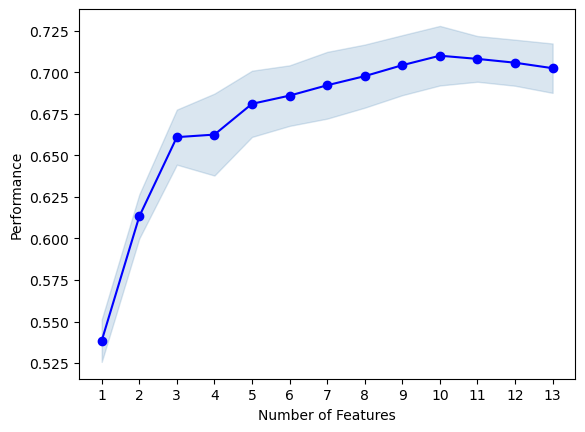

In [97]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sfs.get_metric_dict(), kind='std_err')
import matplotlib.pyplot as plt
plt.show()

# Sequencial Forward selection


It’s a feature selection method that builds up the feature set step by step, starting from zero features and adding one feature at a time until you reach the desired number of features (or performance stops improving).

It’s a greedy search — it doesn’t try every possible combination (that’s exhaustive search), but instead always picks the “best next feature” at each step.

🔹 Process of Sequential Forward Selection

Start empty
Begin with an empty feature subset.

Step 1: Pick the best single feature

Train your model using each feature individually.

Evaluate performance (e.g., with cross-validated R², accuracy, etc.).

Select the feature that gives the best score.

Add it to the subset.

Step 2: Pick the next best feature

Try adding each remaining feature (one at a time) to the already selected subset.

Evaluate the model with each candidate.

Pick the one that improves performance the most.

Add it to the subset.

Repeat until...

You reach the desired number of features (k_features), or

Adding more features no longer improves performance (depending on your stopping rule).

✅ Pros

Simpler than exhaustive search.

Works well when number of features is moderate.

Greedy, so it’s fast compared to brute force.

❌ Cons

Greedy → might miss the globally best subset.

Still computationally expensive if you have hundreds/thousands of features.

Doesn’t automatically remove features that later become redundant (unless you use Sequential Floating Selection).

✅ In short:
Sequential Forward Selection = build your feature set one by one, always adding the feature that gives the biggest performance improvement at that step.

Which is better backward selection for forward selection?

Lots of features → Forward Selection

Few features, want deeper interactions → Backward Selection

🔹 Wrapper Methods

How it works: Use the actual model performance to evaluate subsets of features.

Examples:

Forward Selection

Backward Elimination

Recursive Feature Elimination (RFE)

Pros: Takes feature interactions into account, often better predictive power.

Cons: Computationally expensive (need to train/test many models).